In [43]:
!pip install bayesflow tensorflow

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import bayesflow as bf
import pandas as pd
import seaborn as sns

import pickle

In [45]:
import tensorflow as tf

print("=" * 60)
print("TensorFlow:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("✅ Running on GPU")
    print(gpus)
else:
    print("❌ Running on CPU")
print("=" * 60)

TensorFlow: 2.20.0
✅ Running on GPU
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


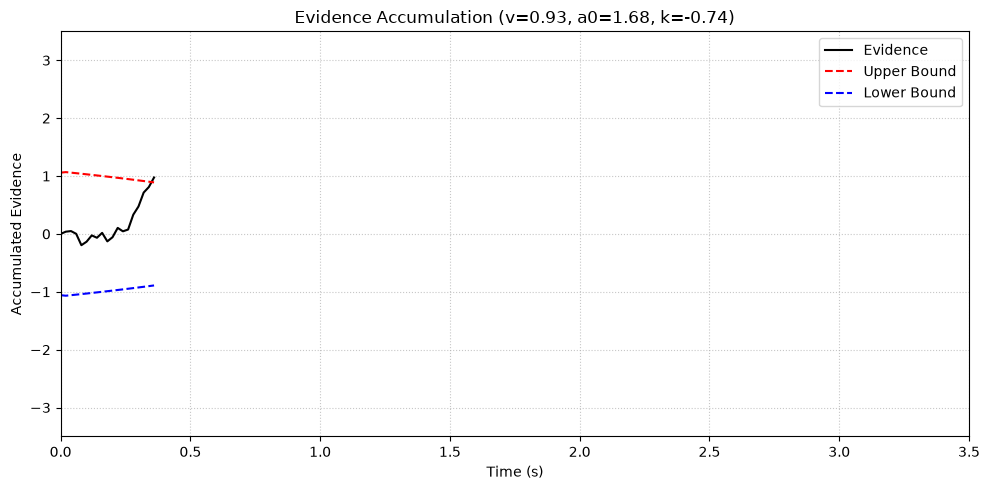

In [48]:
class DDMcollapsingBoundary:
    def __init__(self, drift, k, a0, dt=0.02, max_t=1.35):
        self.v = drift
        self.k = k
        self.a0 = a0
        self.dt = dt
        self.max_t = max_t

    def evidence_accumulation_analysis(self):
        x = 0
        steps = int(self.max_t / self.dt)
        trajectory = [x]
        boundary = [self.a0 * (1 - np.exp(self.k * (1.35 - self.dt)))]
        for i in range(steps):
            t = i * self.dt
            a_t = self.a0 * (1 - np.exp(self.k * (1.35 - t)))
            boundary.append(a_t)
            dx = self.v * self.dt + np.sqrt(self.dt) * np.random.randn()
            x += dx
            trajectory.append(x)
            if x >= a_t:
                return t, 1, trajectory, boundary
            elif x <= -a_t:
                return t, 0, trajectory, boundary
        return self.max_t, 1 if x > 0 else 0, trajectory, boundary

    def evidence_accumulation(self):
        x = 0
        steps = int(self.max_t / self.dt)
        for i in range(steps):
            t = i * self.dt
            a_t = self.a0 * (1 - np.exp(self.k * (self.max_t - t)))
            dx = self.v * self.dt + np.sqrt(self.dt) * np.random.randn()
            x += dx
            if x >= a_t:
                return t, 1
            elif x <= -a_t:
                return t, 0
        return self.max_t, 1 if x > 0 else 0

model = DDMcollapsingBoundary(drift = np.random.normal(1.2, 1.0), k = -0.6 - 0.4*np.random.gamma(2, 0.5), a0 = 1.6 + 0.15*np.random.gamma(2, 0.5))
time, response, trajectory, boundary = model.evidence_accumulation_analysis()

times = np.arange(len(trajectory)) * model.dt

plt.figure(figsize=(10, 5))
plt.plot(times, trajectory, label="Evidence", color='black')
plt.plot(times, boundary, label="Upper Bound", color='red', linestyle='--')
plt.plot(times, [-b for b in boundary], label="Lower Bound", color='blue', linestyle='--')
plt.xlabel("Time (s)")
plt.xlim(0, 3.5)
plt.ylim(-3.5, 3.5)
plt.ylabel("Accumulated Evidence")

# Title with parameter values
plt.title(f"Evidence Accumulation (v={model.v:.2f}, a0={model.a0:.2f}, k={model.k:.2f})")

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()



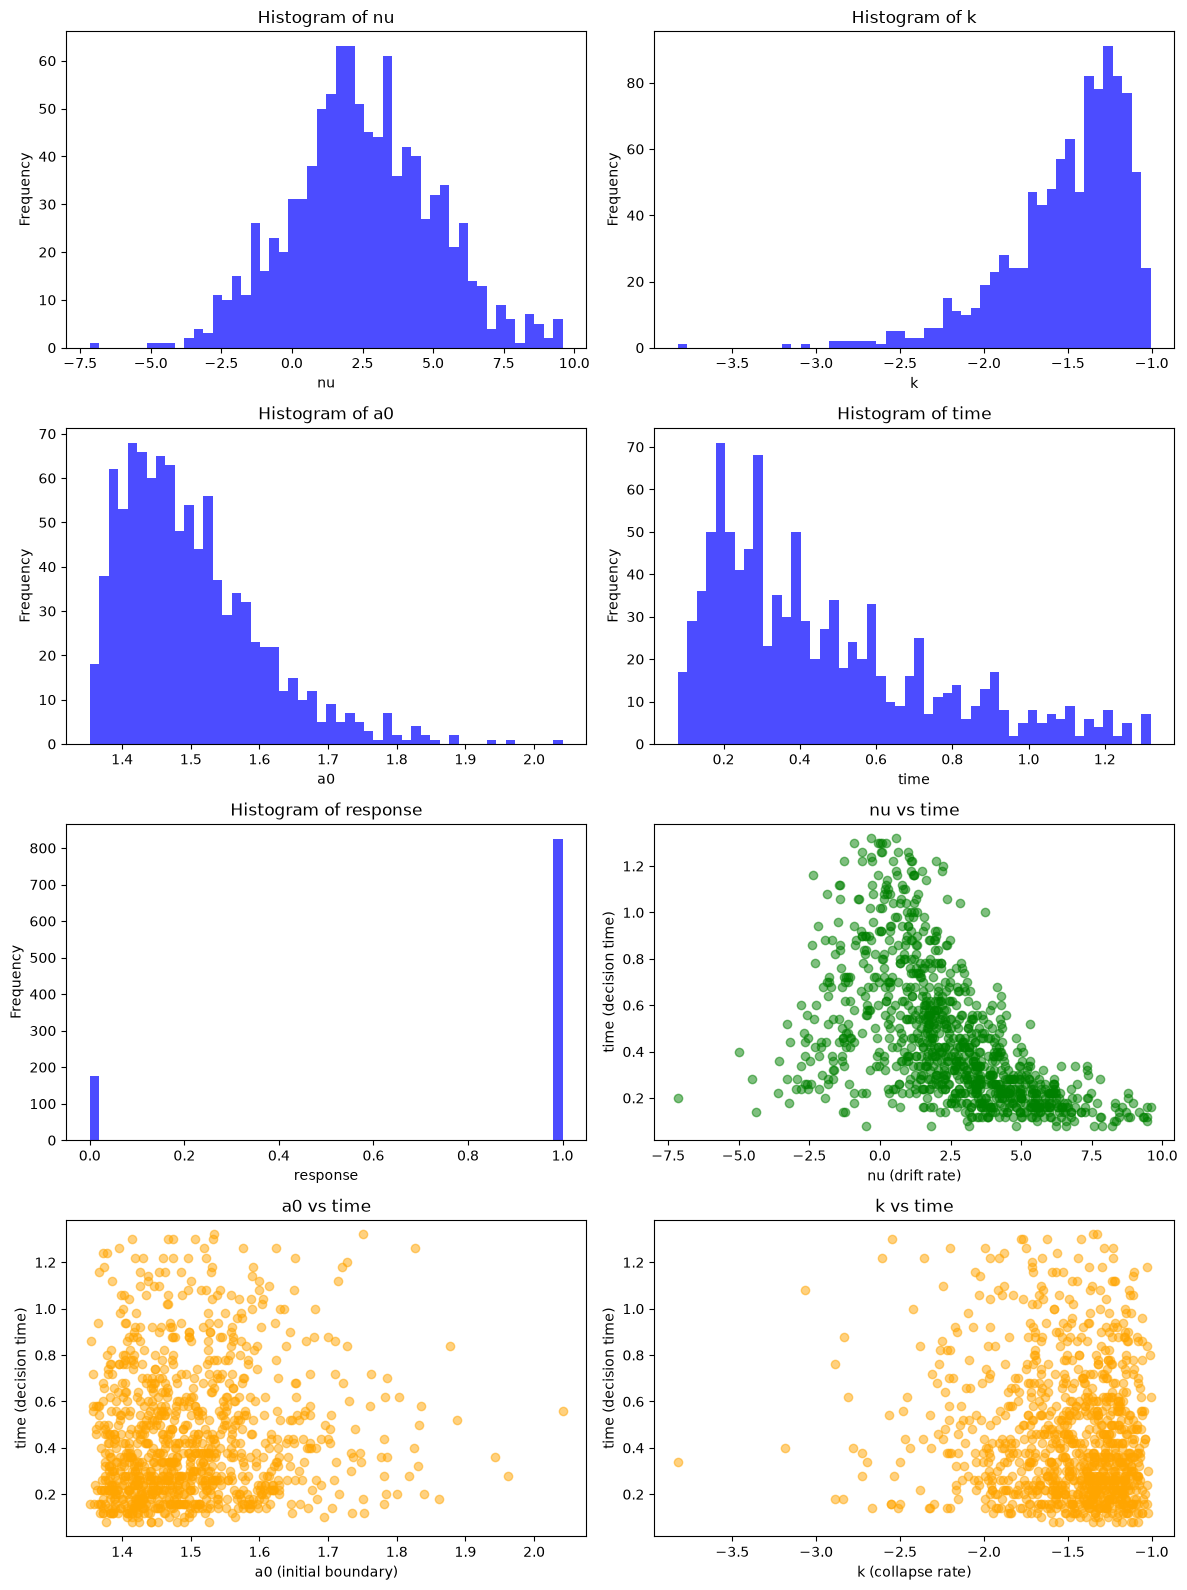

In [49]:
from scipy.stats import truncnorm

nu_list = []
k_list = []
a0_list = []
time_list = []
response_list = []

for i in range(1000):
    nu = 5*np.random.normal(0.5, 0.5)
    k = -1 - 0.5*np.random.gamma(2, 0.5)
    a0 = 1.35 + 0.15*np.random.gamma(2, 0.5)

    model = DDMcollapsingBoundary(nu, k, a0)
    time, response, trajectory, boundary = model.evidence_accumulation_analysis()

    nu_list.append(nu)
    k_list.append(k)
    a0_list.append(a0)
    time_list.append(time)
    response_list.append(response)

# Create DataFrame
df = pd.DataFrame({
    'nu': nu_list,
    'k': k_list,
    'a0': a0_list,
    'time': time_list,
    'response': response_list
})

# Plot histograms and scatter plot
columns = ['nu', 'k', 'a0', 'time', 'response']
fig, axes = plt.subplots(4, 2, figsize=(12, 16))  # 3 rows, 2 columns
axes = axes.flatten()  # Flatten axes array

# Plot histograms
for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=50, color='blue', alpha=0.7)
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Scatter plot: nu vs time
axes[5].scatter(df['nu'], df['time'], alpha=0.5, color='green')
axes[5].set_title("nu vs time")
axes[5].set_xlabel("nu (drift rate)")
axes[5].set_ylabel("time (decision time)")

# Scatter plot: a0 vs time
axes[6].scatter(df['a0'], df['time'], alpha=0.5, color='orange')
axes[6].set_title("a0 vs time")
axes[6].set_xlabel("a0 (initial boundary)")
axes[6].set_ylabel("time (decision time)")

# Scatter plot: k vs time
axes[7].scatter(df['k'], df['time'], alpha=0.5, color='orange')
axes[7].set_title("k vs time")
axes[7].set_xlabel("k (collapse rate)")
axes[7].set_ylabel("time (decision time)")

plt.tight_layout()
plt.show()

In [50]:
def context(n=None):
    if n is None:
        n = 200
    return dict(n=n)

def prior(nu=None, k=None):
    nu = np.random.normal(1.2, 1.0)
    k = -0.6 - 0.4*np.random.gamma(2, 0.5)
    a0 = 1.6 + 0.15*np.random.gamma(2, 0.5)

    return dict(nu=nu, k=k, a0=a0)

def simulate_ddm_trial(v, k, a0):
    model = DDMcollapsingBoundary(v, k, a0)
    return model.evidence_accumulation()

def likelihood(nu, k, a0, n = 200, max_n=200):
    rt = np.zeros(max_n)
    response = np.zeros(max_n)
    for i in range(n):
        result = simulate_ddm_trial(nu, k, a0)
        rt[i] = result[0]
        response[i] = result[1]
    return dict(rt=rt, acc=response)

simulator = bf.make_simulator([context, prior, likelihood])

simulator.sample(1)

{'n': array([[200]]),
 'nu': array([[2.04528263]]),
 'k': array([[-0.94070072]]),
 'a0': array([[1.7154904]]),
 'rt': array([[0.54, 0.38, 0.88, 0.76, 0.7 , 0.4 , 0.34, 0.62, 0.18, 0.78, 0.54,
         0.76, 0.24, 0.6 , 0.9 , 0.44, 0.4 , 0.16, 0.34, 0.24, 0.36, 0.54,
         0.5 , 0.34, 0.82, 0.46, 0.6 , 0.9 , 0.66, 0.82, 0.38, 0.32, 0.58,
         0.3 , 1.08, 0.26, 0.66, 0.72, 0.44, 0.5 , 0.78, 0.38, 0.4 , 0.22,
         0.56, 0.84, 0.42, 0.42, 0.28, 0.36, 0.56, 0.16, 0.24, 0.46, 1.08,
         0.22, 0.6 , 0.54, 0.42, 0.26, 0.46, 0.6 , 0.8 , 0.24, 0.36, 0.52,
         0.38, 0.68, 0.38, 0.34, 0.48, 0.46, 0.38, 0.18, 0.16, 0.36, 0.32,
         0.92, 0.54, 0.44, 0.5 , 0.48, 0.58, 0.26, 1.12, 1.08, 0.38, 0.46,
         0.62, 0.26, 0.78, 0.46, 0.56, 0.3 , 0.52, 0.64, 0.42, 0.36, 0.52,
         0.48, 0.46, 0.88, 0.7 , 0.66, 0.12, 0.38, 0.42, 0.86, 0.44, 0.48,
         0.16, 0.44, 0.28, 0.96, 0.26, 1.04, 0.84, 0.3 , 0.32, 0.3 , 0.38,
         0.26, 0.48, 0.26, 0.48, 0.54, 0.3 , 0.52, 0.3 , 0

In [51]:
# ============================================================
# LOAD AND PREPARE EMPIRICAL EXPERIMENT DATA
# ============================================================

!pip install -q pyreadr

import pyreadr
import pandas as pd
import numpy as np

# Load the RData file
exp1 = pyreadr.read_r("experiment-1-RDM.Rdata")

# Extract the first dataframe stored in the RData file
first_key = list(exp1.keys())[0]
df1 = exp1[first_key].copy()

# Create condition labels
df1["condition"] = (
    df1["deadline"].astype(str)
    + "_"
    + df1["cue"].astype(str)
)

# Display the first few rows
display(df1.head())

# Check the available condition names
print("Conditions found:")
print(df1["condition"].unique())

# Summarize empirical data by condition
condition_summary = (
    df1.groupby("condition", as_index=False)
    .agg(
        mean_rt=("rt", "mean"),
        n_trials=("rt", "count"),
        mean_accuracy=("acc", "mean"),
    )
)

display(condition_summary)

,coherence,rt,acc,pp,deadline,cue,condition
0,0.03,1.009977,1,0,Deadline,AC,Deadline_AC
1,0.03,0.826265,0,0,Deadline,AC,Deadline_AC
2,0.03,1.159891,1,0,Deadline,AC,Deadline_AC
3,0.03,0.726720,1,0,Deadline,AC,Deadline_AC
4,0.03,0.709906,1,0,Deadline,AC,Deadline_AC


Conditions found:
<ArrowStringArray>
['Deadline_AC', 'Deadline_SP', 'No Deadline_AC', 'No Deadline_SP']
Length: 4, dtype: str


,condition,mean_rt,n_trials,mean_accuracy
0,Deadline_AC,0.563501,4732,0.844041
1,Deadline_SP,0.493483,4743,0.722328
2,No Deadline_AC,0.784126,4799,0.891436
3,No Deadline_SP,0.571741,4798,0.783451


In [52]:
"""
def prior(nu=None, k=None):
    nu = 5*np.random.normal(0.5, 0.5)
    k = -1 - 0.5*np.random.gamma(2, 0.5)
    a0 = 1.85 + 0.1*np.random.gamma(2, 0.5)

    return dict(nu=nu, k=k, a0=a0)


General idea : Nu leans positive but not all the time because of proportion of inaccuracy
k is always negative (minus always positive) to reflect collapse rate
a0 is initial distance(atleast a parameter directly proportional to it )


Would prefer K to collapse quickly in terms of the deadline experiment which is reflected well within this prior
but a0 could be larger because the high collapse rigth allows for network to learn boundary gap better
nu is perfect especially
could try :a0 = np.random.lognormal(np.log(1.8),0.3)

Goal: Look for RTs and accuracy that matches real life or the experiment with a clear amount of fast responses
"""

def prior(nu=None, k=None):
    nu = 5*np.random.normal(0.5, 0.5)
    k = -1 - 0.5*np.random.gamma(2, 0.5)
    a0 = 1.35 + 0.15*np.random.gamma(2, 0.5)

    return dict(nu=nu, k=k, a0=a0)


def Original_prior(nu=None, k=None):
    nu = np.random.normal(1.2, 1.0)
    k = -0.6 - 0.4*np.random.gamma(2, 0.5)
    a0 = 1.6 + 0.15*np.random.gamma(2, 0.5)
    return dict(nu=nu, k=k, a0=a0)

def broad_prior():
  #minimal assumptions to cover range
    nu = np.random.normal(0,3)

    k = -np.random.gamma(2,0.5)

    a0 = np.random.lognormal(np.log(1.5),0.5)
    return dict(nu=nu, k=k, a0=a0)

def info_prior():
  #Human reactions have a much lesser extreme collpase rate
  #Other paramters also range adjusted with respect to actual human interaction
    nu = np.random.normal(0,2)

    k = -np.random.gamma(2,0.3)

    a0 = np.random.lognormal(np.log(1.8),0.25)

    return dict(nu=nu, k=k, a0=a0)

def lit_prior():
    nu = np.random.normal(2,1)

    k = -np.random.normal(1,0.2)

    a0 = np.random.normal(1.8,0.2)
    return dict(nu=nu, k=k, a0=a0)

original_prior_simulator = bf.make_simulator([context, Original_prior, likelihood])
broad_simulator = bf.make_simulator([context, broad_prior, likelihood])
info_simulator = bf.make_simulator([context, info_prior, likelihood])
lit_simulator = bf.make_simulator([context, lit_prior, likelihood])

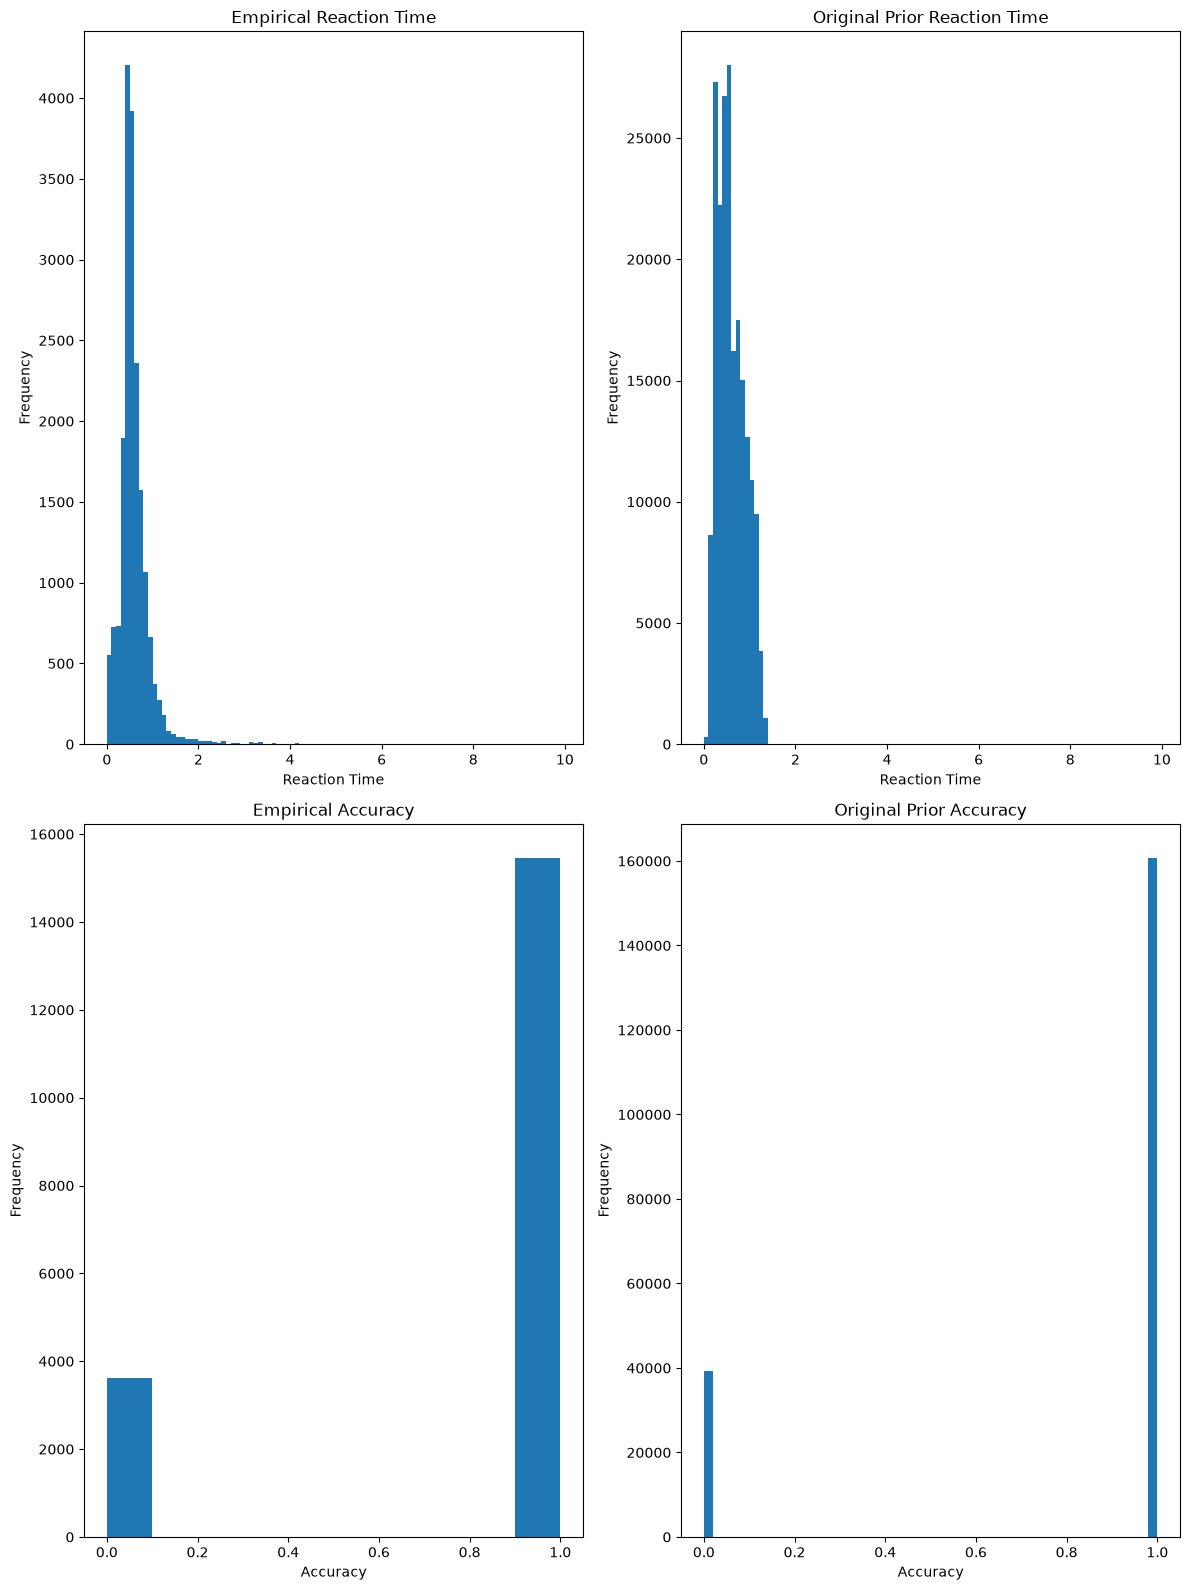

Original Prior Reaction time mean : 0.5981122
Original Prior Reaction time Std Dev : 0.29295016847778055
Original Prior Accuracy : 0.80354
Empirical Reaction time mean : 0.6036762659968163
Empirical Reaction time std Dev : 0.43092825989878103
Empirical Accuracy : 0.8104551174496645
              Original Prior  Empirical
Accuracy            0.803540   0.810455
Mean                0.598112   0.603676
Std                 0.292950   0.430928
Median              0.560000   0.526607
10% quantile        0.240000   0.293126
90% quantile        1.040000   0.926287


In [53]:
# ============================================================
# PRIOR PREDICTIVE CHECK FOR Original_prior
# Logic matched to DDM_updated_(Prior_Pred_Checks_inserted).ipynb
# ============================================================

prior_samples = simulator.sample(1000)
original_prior_samples = original_prior_simulator.sample(1000)
broad_prior_samples = broad_simulator.sample(1000)
info_prior_samples = info_simulator.sample(1000)
lit_prior_samples = lit_simulator.sample(1000)

# RT bins aligned to the simulator grid: 0.10 s = 5 * dt.
rt_bin_width = 0.10
prior_rt_bins = np.arange(
    0.0,
    DDMcollapsingBoundary(0, -1, 1).max_t + rt_bin_width + 1e-12,
    rt_bin_width,
)
empirical_rt_bins = np.arange(
    0.0,
    df1["rt"].max() + rt_bin_width + 1e-12,
    rt_bin_width,
)


fig, axes = plt.subplots(2, 2, figsize=(12, 16))
axes = axes.flatten()

axes[0].hist(df1["rt"], bins=empirical_rt_bins)
axes[0].set_xlabel("Reaction Time")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Empirical Reaction Time")

axes[1].hist(original_prior_samples["rt"].flatten(), bins=empirical_rt_bins)
axes[1].set_xlabel("Reaction Time")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Original Prior Reaction Time")

axes[2].hist(df1["acc"])
axes[2].set_xlabel("Accuracy")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Empirical Accuracy")

axes[3].hist(original_prior_samples["acc"].flatten(), bins=50)
axes[3].set_xlabel("Accuracy")
axes[3].set_ylabel("Frequency")
axes[3].set_title("Original Prior Accuracy")

plt.tight_layout()
plt.show()

print("Original Prior Reaction time mean :", original_prior_samples["rt"].mean())
print("Original Prior Reaction time Std Dev :", original_prior_samples["rt"].std())
print("Original Prior Accuracy :", original_prior_samples["acc"].mean())

print("Empirical Reaction time mean :", df1["rt"].mean())
print("Empirical Reaction time std Dev :", df1["rt"].std())
print("Empirical Accuracy :", df1["acc"].mean())

original_prior_pc_samples = {
    "Original Prior": original_prior_samples,
    "Empirical": df1,
}

original_prior_pc_table = pd.DataFrame({
    name: {
        "Accuracy": samples["acc"].mean(),
        "Mean": samples["rt"].mean(),
        "Std": samples["rt"].std(),
        "Median": np.quantile(samples["rt"], 0.5),
        "10% quantile": np.quantile(samples["rt"], 0.1),
        "90% quantile": np.quantile(samples["rt"], 0.9),
    }
    for name, samples in original_prior_pc_samples.items()
})

print(original_prior_pc_table)


                 Prior  Original Prior     Broad     Info       Lit  Empirical
Mean          0.601617        0.598112  0.390609  0.37526  0.518515   0.603676
Std           0.289301        0.292950  0.327805  0.29959  0.269723   0.430928
Median        0.560000        0.560000  0.300000  0.30000  0.460000   0.526607
10% quantile  0.260000        0.240000  0.060000  0.06000  0.220000   0.293126
90% quantile  1.040000        1.040000  0.900000  0.82000  0.920000   0.926287


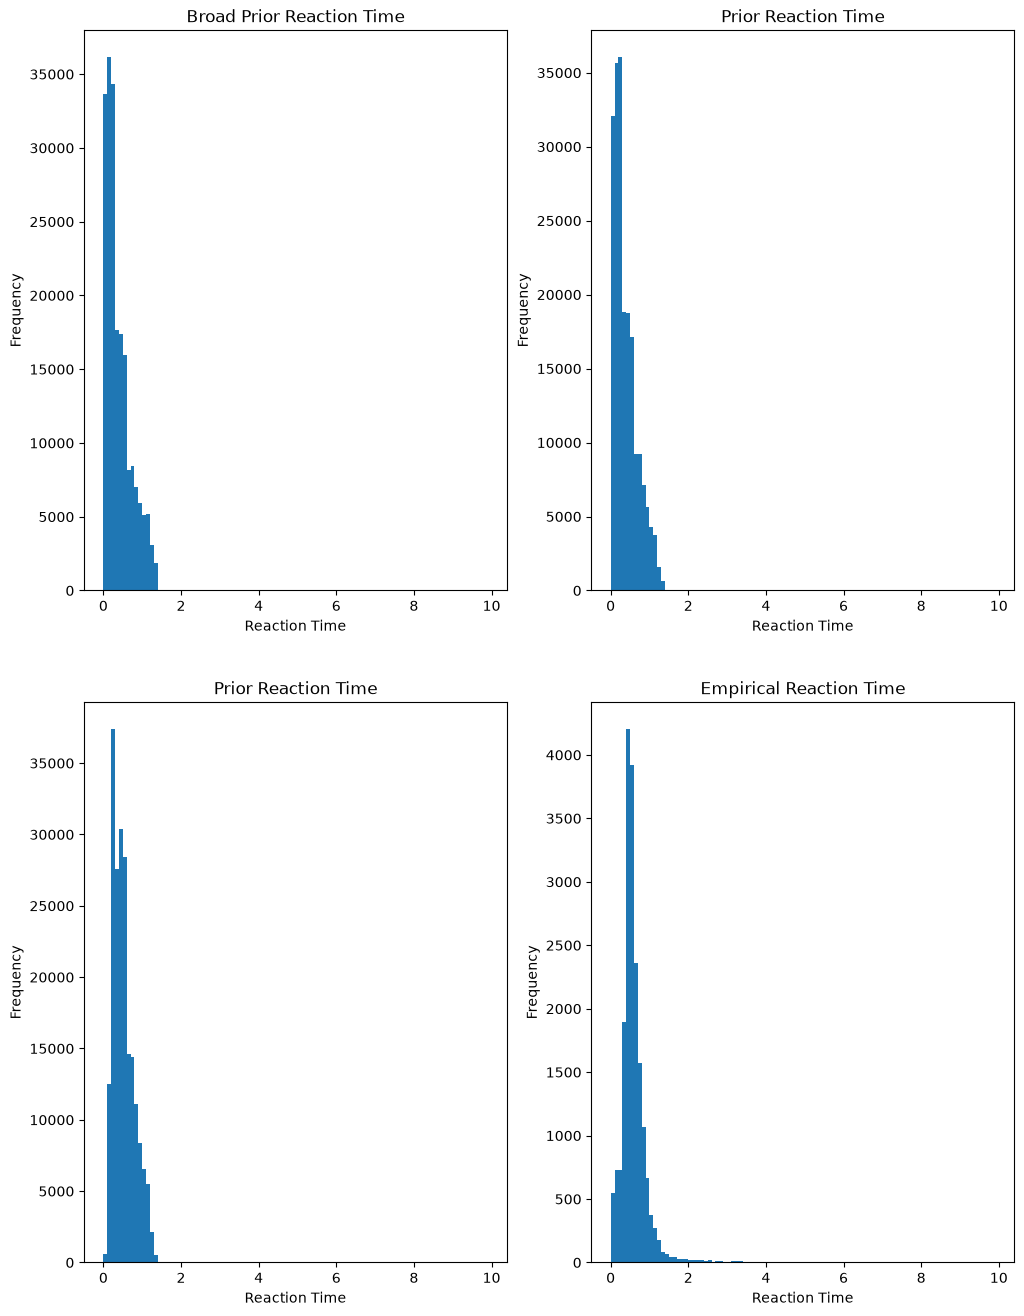

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(12, 16))
axes = axes.flatten()  # Flatten axes array
axes[0].hist(broad_prior_samples["rt"].flatten(), bins=empirical_rt_bins)
axes[0].set_xlabel("Reaction Time")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Broad Prior Reaction Time")

axes[1].hist(info_prior_samples['rt'].flatten(), bins=empirical_rt_bins)
axes[1].set_xlabel("Reaction Time")
axes[1].set_ylabel("Frequency")
axes[1].set_title("info_Prior Reaction Time")

axes[2].hist(lit_prior_samples['rt'].flatten(), bins=empirical_rt_bins)
axes[2].set_xlabel("Reaction Time")
axes[2].set_ylabel("Frequency")
axes[2].set_title("lit_Prior Reaction Time")


axes[3].hist(df1["rt"], bins=empirical_rt_bins)
axes[3].set_xlabel("Reaction Time")
axes[3].set_ylabel("Frequency")
axes[3].set_title("Empirical Reaction Time")
"""
print("Broad Prior Reaction time mean :",broad_prior_samples["rt"].mean())
print("Literature Prior Reaction time mean :",lit_prior_samples["rt"].mean())
print("Informative Prior Reaction time mean :",info_prior_samples["rt"].mean())

print("Broad Prior Reaction time Std Dev :",broad_prior_samples["rt"].std())
print("Literature Prior Reaction time Std Dev :",lit_prior_samples["rt"].std())
print("informative Prior Reaction time Std Dev :",info_prior_samples["rt"].std())



print("Empirical Reaction time mean :",df1["rt"].mean())
print("Empirical Reaction time std Dev :",df1["rt"].std())
"""
priors={"Prior":prior_samples,"Original Prior":original_prior_samples,"Broad":broad_prior_samples,"Info":info_prior_samples,"Lit":lit_prior_samples,"Empirical":df1}
table = pd.DataFrame({
    name: {
        "Mean": samples['rt'].mean(),
        "Std": samples['rt'].std(),
        "Median": np.quantile(samples['rt'], 0.5),
        "10% quantile": np.quantile(samples['rt'], 0.1),
        #"25% quantile": np.quantile(samples['rt'], 0.25),
        #"75% quantile": np.quantile(samples['rt'], 0.75),
        "90% quantile":np.quantile(samples['rt'], 0.9),
    }
    for name, samples in priors.items()
})

print(table)

In [65]:
sim_data = simulator.sample(10000)

nu_mean, nu_std = sim_data['nu'].mean(), sim_data['nu'].std()
k_mean, k_std = sim_data['k'].mean(), sim_data['k'].std()
a0_mean, a0_std = sim_data['a0'].mean(), sim_data['a0'].std()
rt_mean, rt_std = sim_data['rt'].mean(), sim_data['rt'].std()


adapter = (bf.Adapter()
    .as_set(["rt","acc"])
    .constrain("k", upper=0)
    .constrain("a0", lower=0)
    .standardize(include="nu", mean=nu_mean, std=nu_std)
    .standardize(include="k", mean=k_mean, std=k_std)
    .standardize(include="a0", mean=a0_mean, std=a0_std)
    .standardize(include="rt", mean=rt_mean, std=rt_std)
    .concatenate(["nu", "k", "a0"], into="inference_variables")
    .concatenate(["rt", "acc"], into="summary_variables")
)

workflow = bf.BasicWorkflow(
    simulator = simulator,
    adapter = adapter,
    inference_network = bf.networks.FlowMatching(
        depth=8,
        subnet_kwargs=dict(dropout=False)
    ),
    summary_network = bf.networks.DeepSet(
        depth=8,
        base_distribution="normal",
        dropout=False
    ),
    initial_learning_rate = 1e-3,
    inference_variables = ["nu", "k", "a0"],
    summary_variables = ["rt", "acc"]
)

In [66]:
train_data = simulator.sample(5000)
validation_data = simulator.sample(100)
test_data = simulator.sample(500)

In [67]:
history=workflow.fit_offline(
    data=train_data,
    epochs=150,
    batch_size=100,
    validation_data=validation_data
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - loss: 1.0223 - loss/inference_loss: 0.7884 - loss/summary_loss: 0.2339 - val_loss: 1.2817 - val_loss/inference_loss: 1.0587 - val_loss/summary_loss: 0.2230
Epoch 2/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.2392 - loss/inference_loss: 1.0388 - loss/summary_loss: 0.2005 - val_loss: 1.1817 - val_loss/inference_loss: 0.9658 - val_loss/summary_loss: 0.2159
Epoch 3/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.1017 - loss/inference_loss: 0.8450 - loss/summary_loss: 0.2567 - val_loss: 1.0619 - val_loss/inference_loss: 0.8375 - val_loss/summary_loss: 0.2244
Epoch 4/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 1.2697 - loss/inference_loss: 1.0421 - loss/summary_loss: 0.2276 - val_loss: 1.1519 - val_loss/inference_loss: 0.9341 - val_loss/summary_loss: 0.2178
Epoch 5/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.9503 - loss/inference_loss: 0.7538 - loss/summary_loss: 0.1965 - val_loss: 1.1220 - val_loss/infe

INFO:bayesflow:Training completed in 4.49 minutes.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

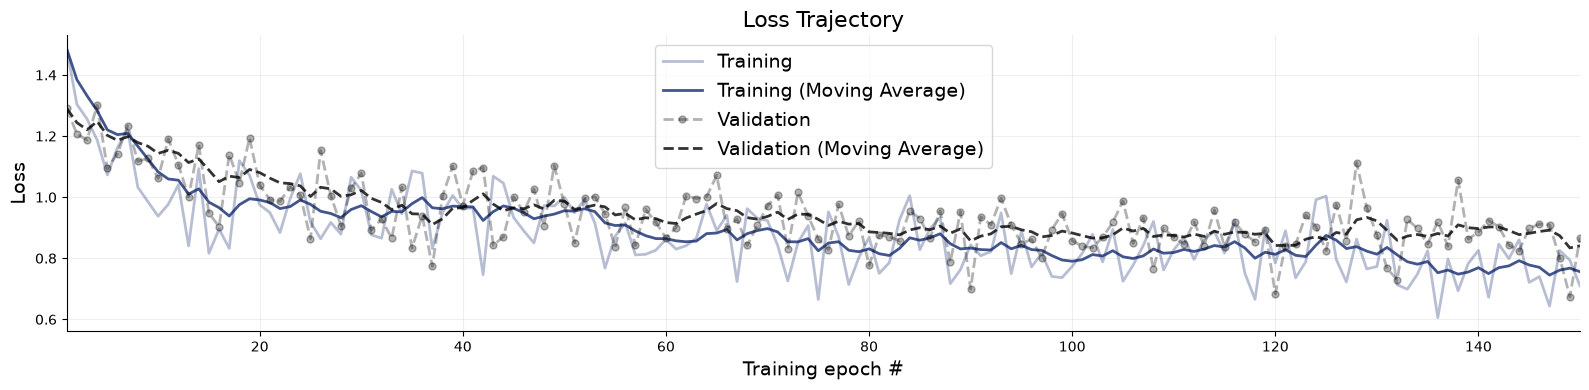

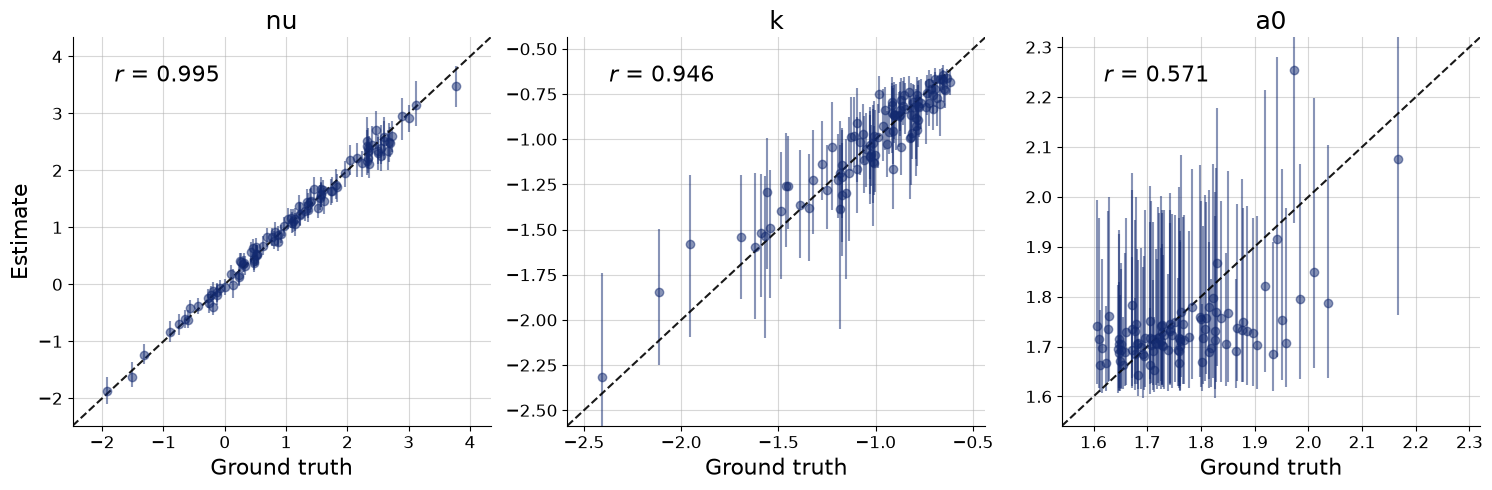

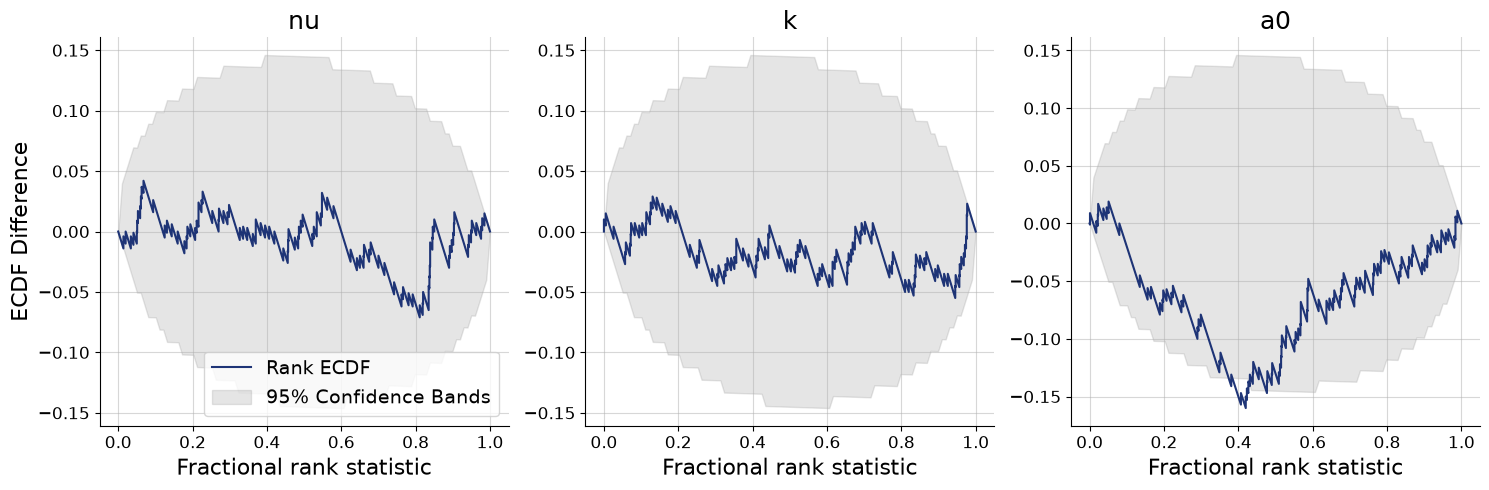

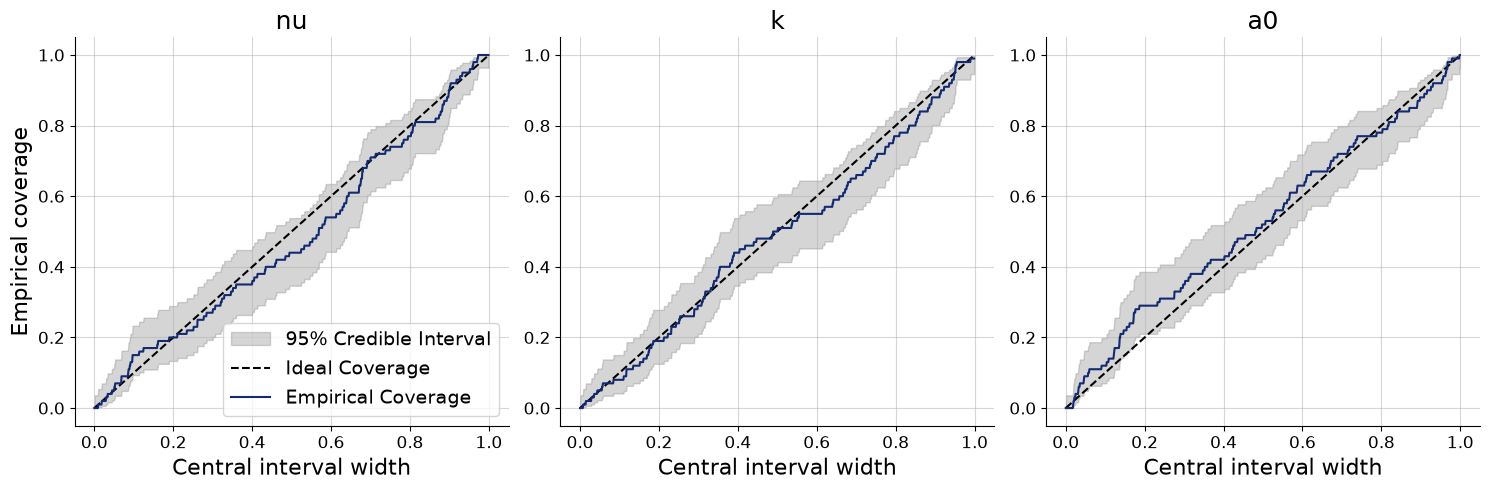

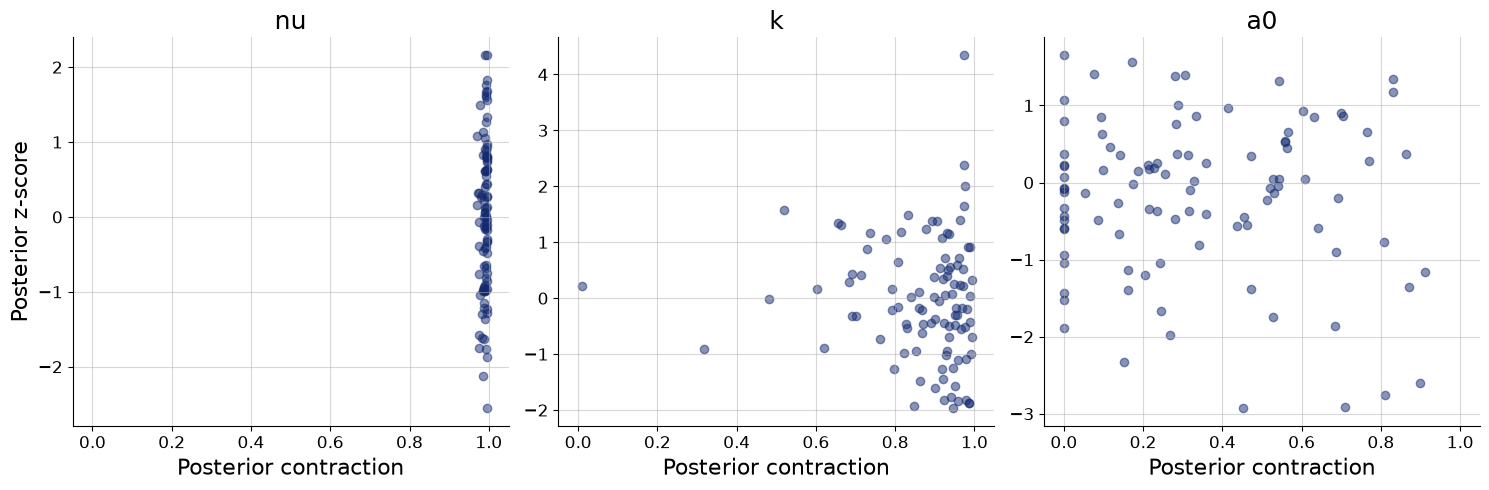

In [58]:
plots=workflow.plot_default_diagnostics(test_data=simulator.sample(100))

In [ ]:
# !pip install pyreadr
# import pyreadr
# exp1 = pyreadr.read_r('experiment-1-RDM.Rdata')

# first_key = list(exp1.keys())[0]
# df1 = exp1[first_key]
# df1.head()

In [ ]:
# df1['condition'] = df1['deadline'].astype(str) + '_' + df1['cue'].astype(str)
# df1.groupby('condition', as_index=False).agg({'rt':['mean','count'],'acc':'mean'})

In [ ]:
# TRIALS_PER_CONDITION = 800

# grouped = df1.groupby('condition')
# data_inference_dict = {}
# for key in ['rt', 'acc']:
#     stacked = []
#     for _, group in grouped:
#         vals = group[key].values[:TRIALS_PER_CONDITION]
#         if len(vals) < TRIALS_PER_CONDITION:
#             raise ValueError(f"Group smaller than {TRIALS_PER_CONDITION} trials: {len(vals)}")
#         stacked.append(vals.reshape(TRIALS_PER_CONDITION, 1))
#     data_inference_dict[key] = np.array(stacked)

In [68]:
TRIALS_PER_CONDITION = 800

condition_order = [
    "Deadline_AC",
    "Deadline_SP",
    "No Deadline_AC",
    "No Deadline_SP",
]

data_inference_dict = {
    "rt": [],
    "acc": [],
}

for condition in condition_order:
    group = df1[df1["condition"] == condition]

    rt_values = group["rt"].to_numpy()[:TRIALS_PER_CONDITION]
    acc_values = group["acc"].to_numpy()[:TRIALS_PER_CONDITION]

    if len(rt_values) < TRIALS_PER_CONDITION:
        raise ValueError(
            f"{condition} contains only {len(rt_values)} trials; "
            f"{TRIALS_PER_CONDITION} are required."
        )

    data_inference_dict["rt"].append(
        rt_values.reshape(TRIALS_PER_CONDITION, 1)
    )

    data_inference_dict["acc"].append(
        acc_values.reshape(TRIALS_PER_CONDITION, 1)
    )

data_inference_dict["rt"] = np.asarray(
    data_inference_dict["rt"]
)

data_inference_dict["acc"] = np.asarray(
    data_inference_dict["acc"]
)

In [69]:
print("RT shape:", data_inference_dict["rt"].shape)
print("Accuracy shape:", data_inference_dict["acc"].shape)

RT shape: (4, 800, 1)
Accuracy shape: (4, 800, 1)


In [70]:
posterior_samples = workflow.sample(conditions=data_inference_dict, num_samples=500)


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 6.79 seconds.


In [ ]:
# posterior = {key: value[0] for key, value in posterior_samples.items()}

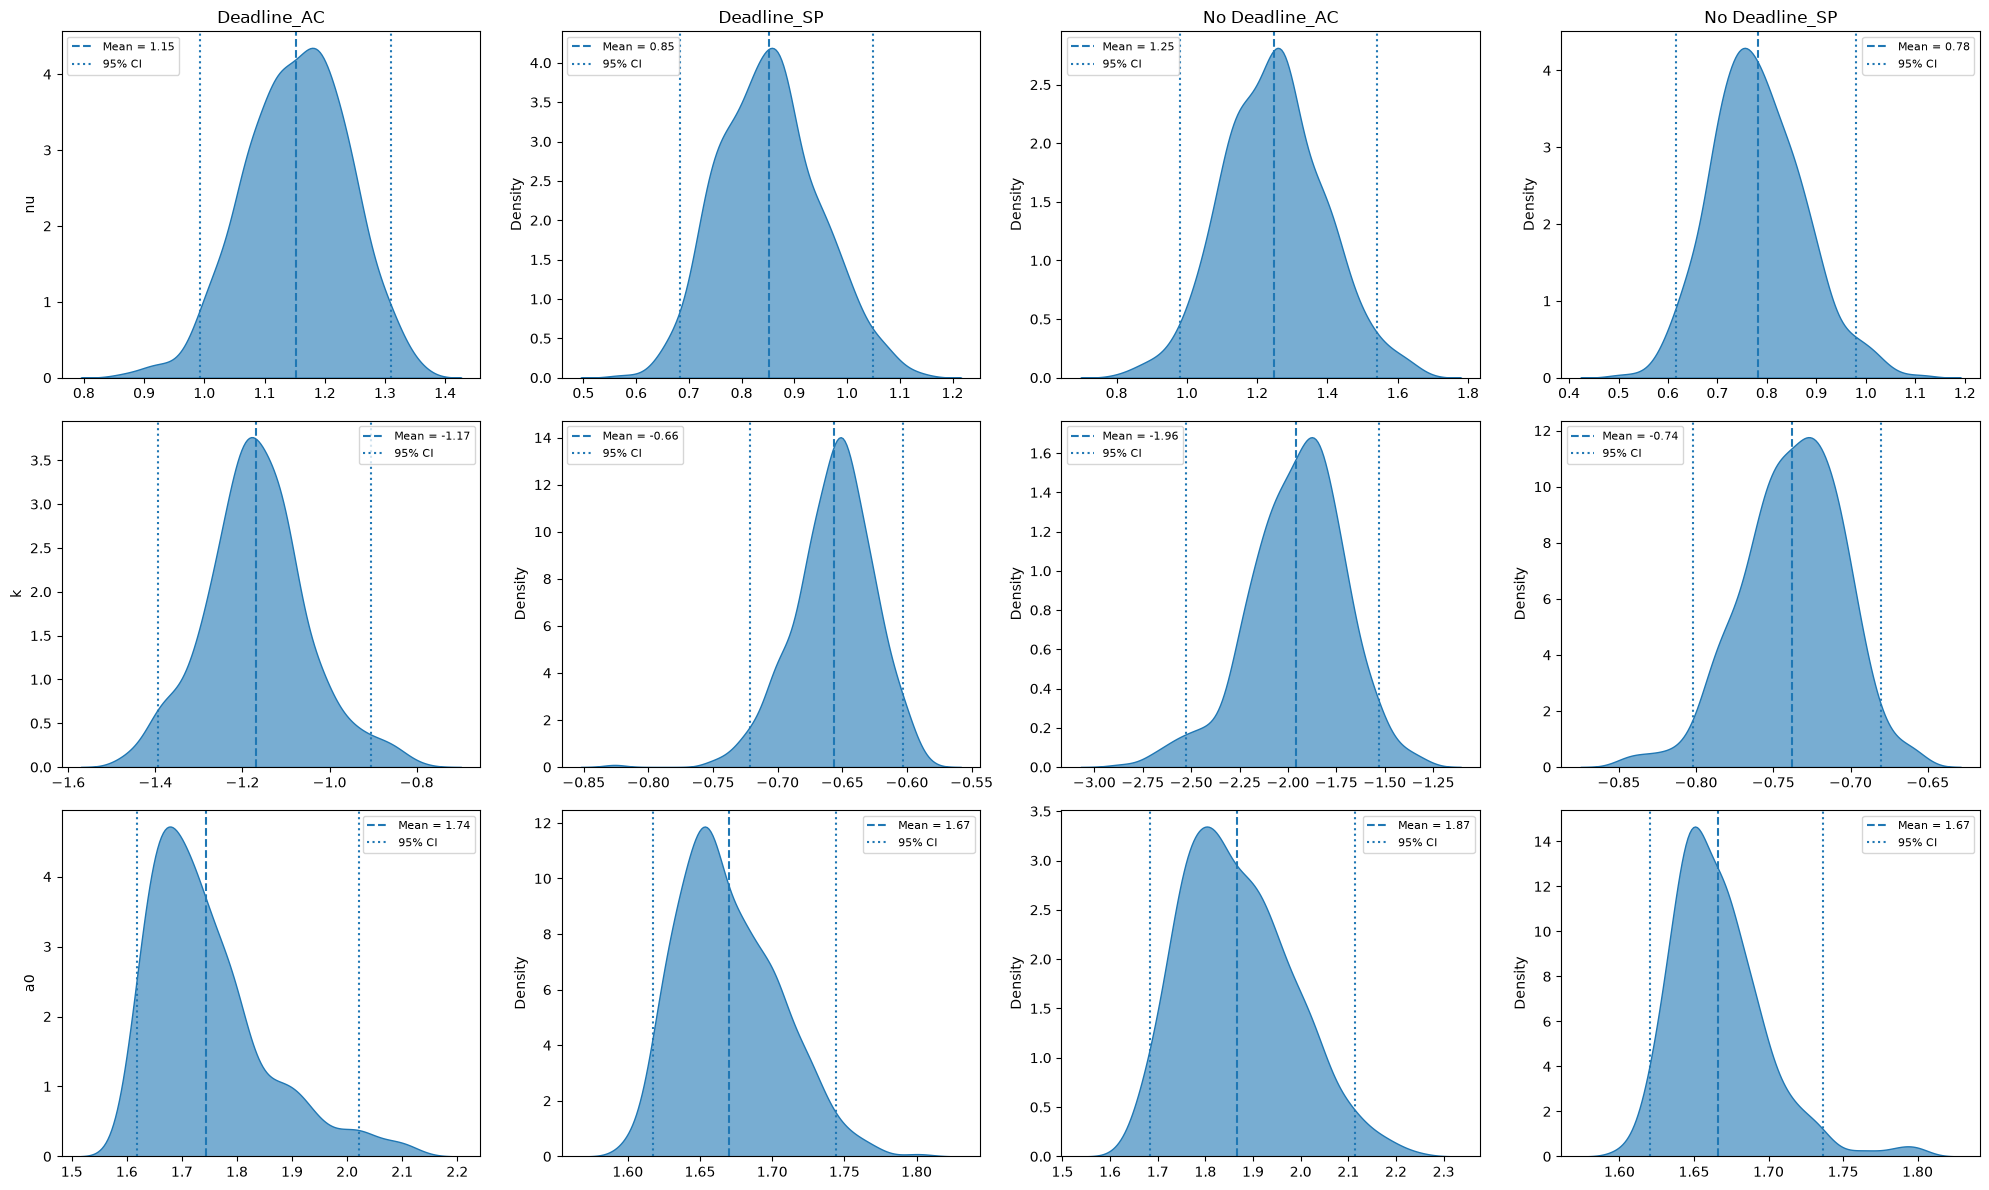

In [71]:
import seaborn as sns

param_names = ["nu", "k", "a0"]
condition_labels = condition_order

fig, axes = plt.subplots(
    len(param_names),
    len(condition_labels),
    figsize=(20, 12),
    sharex=False,
    sharey=False,
)

for row, param in enumerate(param_names):
    for col, condition in enumerate(condition_labels):
        ax = axes[row, col]

        samples = np.asarray(
            posterior_samples[param][col]
        ).squeeze()

        sns.kdeplot(
            samples,
            ax=ax,
            fill=True,
            alpha=0.6,
        )

        mean_value = samples.mean()
        lower, upper = np.quantile(
            samples,
            [0.025, 0.975],
        )

        ax.axvline(
            mean_value,
            linestyle="--",
            label=f"Mean = {mean_value:.2f}",
        )

        ax.axvline(
            lower,
            linestyle=":",
            label="95% CI",
        )

        ax.axvline(
            upper,
            linestyle=":",
        )

        if row == 0:
            ax.set_title(condition)

        if col == 0:
            ax.set_ylabel(param)

        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [72]:
posterior_rows = []

for condition_id, condition in enumerate(condition_order):
    for parameter in ["nu", "k", "a0"]:
        samples = np.asarray(
            posterior_samples[parameter][condition_id]
        ).squeeze()

        lower, upper = np.quantile(
            samples,
            [0.025, 0.975],
        )

        posterior_rows.append({
            "condition": condition,
            "parameter": parameter,
            "mean": samples.mean(),
            "median": np.median(samples),
            "sd": samples.std(),
            "q025": lower,
            "q975": upper,
        })

posterior_summary = pd.DataFrame(posterior_rows)

posterior_summary.round(3)

,condition,parameter,mean,median,sd,q025,q975
0,Deadline_AC,nu,1.153,1.156,0.084,0.994,1.310
1,Deadline_AC,k,-1.168,-1.174,0.116,-1.395,-0.904
2,Deadline_AC,a0,1.745,1.720,0.104,1.618,2.022
3,Deadline_SP,nu,0.852,0.850,0.094,0.683,1.049
4,Deadline_SP,k,-0.657,-0.653,0.030,-0.722,-0.603
5,Deadline_SP,a0,1.670,1.664,0.034,1.618,1.744
6,No Deadline_AC,nu,1.247,1.247,0.143,0.980,1.542
7,No Deadline_AC,k,-1.956,-1.937,0.245,-2.526,-1.528
8,No Deadline_AC,a0,1.867,1.850,0.114,1.683,2.113
9,No Deadline_SP,nu,0.781,0.774,0.092,0.615,0.979


In [ ]:
# import seaborn as sns

# param_names = ['nu', 'k', 'a0']
# condition_labels = ["Deadline_AC", "Deadline_SP", "No Deadline_AC", "No Deadline_SP"]

# fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=False, sharey=False)

# for row, param in enumerate(param_names):
#     for col, cond in enumerate(condition_labels):
#         ax = axes[row, col]

#         # Extract posterior samples for this param and condition
#         samples = posterior_samples[param][col].squeeze()

#         # Plot density
#         sns.kdeplot(samples, ax=ax, fill=True, color="steelblue", alpha=0.6)

#         # Add vertical lines for mean and 95% credible interval
#         mean_val = samples.mean()
#         ci_lower, ci_upper = np.quantile(samples, [0.025, 0.975])
#         ax.axvline(mean_val, color="red", linestyle="--", label=f"Mean = {mean_val:.2f}")
#         ax.axvline(ci_lower, color="black", linestyle=":", label=f"95% CI")
#         ax.axvline(ci_upper, color="black", linestyle=":")

#         # Titles and labels
#         if row == 0:
#             ax.set_title(cond, fontsize=14)
#         if col == 0:
#             ax.set_ylabel(param, fontsize=12)
#         ax.legend(fontsize=9)

# plt.tight_layout()
# plt.show()

In [73]:
import numpy as np
import matplotlib.pyplot as plt


def ppc_ddm(
    posterior,
    trial_simulator,
    obs_rt,
    obs_acc,
    n_reps=200,
    seed=42,
    condition_name=None,
    color="#132a70",
    figsize=(13, 5),
):
    """
    Posterior predictive check for one experimental condition.

    For each selected posterior draw, this function simulates one complete
    replicated dataset with the same number of trials as the observed condition.

    Parameters
    ----------
    posterior : dict
        Dictionary containing posterior samples with keys: "nu", "k", "a0".
        Example:
            posterior["nu"].shape = (num_posterior_samples,)

    trial_simulator : callable
        Function with signature:
            trial_simulator(nu, k, a0) -> (rt, acc_or_choice)

        Important:
        Make sure the second output is comparable to obs_acc.
        If the simulator returns boundary choice instead of true accuracy,
        rename/interpret the PPC accordingly.

    obs_rt : array-like
        Observed response times for one condition.

    obs_acc : array-like
        Observed accuracy or binary response for the same condition.

    n_reps : int
        Number of posterior draws / replicated datasets to simulate.

    seed : int
        Random seed for reproducibility.

    condition_name : str or None
        Name shown in plot titles, e.g. "Deadline_SP".

    Returns
    -------
    fig : matplotlib.figure.Figure
        PPC figure.

    statistics : dict
        Observed statistics, posterior predictive means, intervals,
        and whether observed values fall inside the 95% predictive intervals.
    """

    # Basic validation
    obs_rt = np.asarray(obs_rt, dtype=float).reshape(-1)
    obs_acc = np.asarray(obs_acc, dtype=float).reshape(-1)

    valid_mask = np.isfinite(obs_rt) & np.isfinite(obs_acc)
    obs_rt = obs_rt[valid_mask]
    obs_acc = obs_acc[valid_mask]

    if obs_rt.size == 0:
        raise ValueError("obs_rt and obs_acc must contain at least one valid observation.")

    if obs_rt.size != obs_acc.size:
        raise ValueError("obs_rt and obs_acc must have equal length.")

    required_keys = ["nu", "k", "a0"]
    for key in required_keys:
        if key not in posterior:
            raise KeyError(f"posterior is missing required key: {key}")

    posterior_nu = np.asarray(posterior["nu"]).reshape(-1)
    posterior_k = np.asarray(posterior["k"]).reshape(-1)
    posterior_a0 = np.asarray(posterior["a0"]).reshape(-1)

    n_draws = posterior_nu.shape[0]

    if not (posterior_k.shape[0] == n_draws and posterior_a0.shape[0] == n_draws):
        raise ValueError("posterior['nu'], posterior['k'], and posterior['a0'] must have same length.")

    if n_reps > n_draws:
        raise ValueError(f"n_reps={n_reps} exceeds available posterior draws={n_draws}.")

    # Reproducibility
    rng = np.random.default_rng(seed)

    # Also seed the old global RNG because the existing simulator likely uses np.random.randn()
    np.random.seed(seed)

    draw_ids = rng.choice(n_draws, size=n_reps, replace=False)
    n_trials = obs_rt.size

    pred_rt = np.empty((n_reps, n_trials), dtype=float)
    pred_acc = np.empty((n_reps, n_trials), dtype=float)

    # Simulate one complete replicated dataset per posterior draw
    for rep, draw_id in enumerate(draw_ids):
        nu = float(posterior_nu[draw_id])
        k = float(posterior_k[draw_id])
        a0 = float(posterior_a0[draw_id])

        for trial in range(n_trials):
            rt_sim, acc_sim = trial_simulator(nu, k, a0)
            pred_rt[rep, trial] = rt_sim
            pred_acc[rep, trial] = acc_sim

    # Observed statistics
    observed_accuracy = float(np.mean(obs_acc))
    observed_mean_rt = float(np.mean(obs_rt))
    observed_median_rt = float(np.median(obs_rt))
    observed_rt_sd = float(np.std(obs_rt))
    observed_rt_q10, observed_rt_q50, observed_rt_q90 = np.quantile(obs_rt, [0.10, 0.50, 0.90])

    # One statistic per replicated dataset
    predicted_accuracy = pred_acc.mean(axis=1)
    predicted_mean_rt = pred_rt.mean(axis=1)
    predicted_median_rt = np.median(pred_rt, axis=1)
    predicted_rt_sd = pred_rt.std(axis=1)
    predicted_rt_q10 = np.quantile(pred_rt, 0.10, axis=1)
    predicted_rt_q50 = np.quantile(pred_rt, 0.50, axis=1)
    predicted_rt_q90 = np.quantile(pred_rt, 0.90, axis=1)

    def interval(x):
        return np.quantile(x, [0.025, 0.975])

    accuracy_interval = interval(predicted_accuracy)
    mean_rt_interval = interval(predicted_mean_rt)
    median_rt_interval = interval(predicted_median_rt)
    rt_sd_interval = interval(predicted_rt_sd)
    rt_q10_interval = interval(predicted_rt_q10)
    rt_q50_interval = interval(predicted_rt_q50)
    rt_q90_interval = interval(predicted_rt_q90)

    def inside(value, intv):
        return bool(intv[0] <= value <= intv[1])

    title_prefix = f"{condition_name}: " if condition_name else ""

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # RT distribution PPC
    common_rt_bins = np.histogram_bin_edges(
        np.concatenate([obs_rt, pred_rt.reshape(-1)]),
        bins=30,
    )

    axes[0].hist(
        pred_rt.reshape(-1),
        bins=common_rt_bins,
        density=True,
        color=color,
        alpha=0.45,
        label="Posterior predictive",
    )

    axes[0].hist(
        obs_rt,
        bins=common_rt_bins,
        density=True,
        histtype="step",
        color="black",
        linewidth=2,
        label="Observed",
    )

    axes[0].axvline(
        observed_mean_rt,
        color="black",
        linestyle="--",
        linewidth=1.8,
        label=f"Obs. mean RT = {observed_mean_rt:.3f}",
    )

    axes[0].axvspan(
        mean_rt_interval[0],
        mean_rt_interval[1],
        color=color,
        alpha=0.12,
        label="95% PPI mean RT",
    )

    axes[0].set(
        xlabel="Response time (s)",
        ylabel="Density",
        title=title_prefix + "Response-time PPC",
    )
    axes[0].legend(fontsize=9)

    # Accuracy PPC
    axes[1].hist(
        predicted_accuracy,
        bins=np.linspace(0, 1, 21),
        density=False,
        color=color,
        alpha=0.65,
        label="Replicated accuracy",
    )

    axes[1].axvline(
        observed_accuracy,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Observed = {observed_accuracy:.3f}",
    )

    axes[1].axvspan(
        accuracy_interval[0],
        accuracy_interval[1],
        color=color,
        alpha=0.15,
        label="95% predictive interval",
    )

    axes[1].set(
        xlim=(0, 1),
        xlabel="Proportion correct / response 1",
        ylabel="Replicated datasets",
        title=title_prefix + "Accuracy / response PPC",
    )
    axes[1].legend(fontsize=9)

    fig.tight_layout()

    # Optional correct/error RT summaries
    # These are only meaningful if obs_acc and pred_acc genuinely mean correctness.
    obs_correct_rt = obs_rt[obs_acc == 1]
    obs_error_rt = obs_rt[obs_acc == 0]

    observed_correct_mean_rt = float(np.mean(obs_correct_rt)) if obs_correct_rt.size > 0 else np.nan
    observed_error_mean_rt = float(np.mean(obs_error_rt)) if obs_error_rt.size > 0 else np.nan

    pred_correct_mean_rt = []
    pred_error_mean_rt = []

    for rep in range(n_reps):
        correct_rt = pred_rt[rep, pred_acc[rep] == 1]
        error_rt = pred_rt[rep, pred_acc[rep] == 0]

        pred_correct_mean_rt.append(np.mean(correct_rt) if correct_rt.size > 0 else np.nan)
        pred_error_mean_rt.append(np.mean(error_rt) if error_rt.size > 0 else np.nan)

    pred_correct_mean_rt = np.asarray(pred_correct_mean_rt, dtype=float)
    pred_error_mean_rt = np.asarray(pred_error_mean_rt, dtype=float)

    correct_valid = np.isfinite(pred_correct_mean_rt)
    error_valid = np.isfinite(pred_error_mean_rt)

    correct_mean_rt_interval = (
        interval(pred_correct_mean_rt[correct_valid])
        if np.sum(correct_valid) >= 3
        else np.array([np.nan, np.nan])
    )

    error_mean_rt_interval = (
        interval(pred_error_mean_rt[error_valid])
        if np.sum(error_valid) >= 3
        else np.array([np.nan, np.nan])
    )

    statistics = {
        "condition": condition_name,
        "n_observed_trials": int(n_trials),
        "n_replicated_datasets": int(n_reps),

        "observed_accuracy": observed_accuracy,
        "predicted_accuracy_mean": float(np.mean(predicted_accuracy)),
        "predicted_accuracy_q025": float(accuracy_interval[0]),
        "predicted_accuracy_q975": float(accuracy_interval[1]),
        "accuracy_inside_95ppi": inside(observed_accuracy, accuracy_interval),

        "observed_mean_rt": observed_mean_rt,
        "predicted_mean_rt_mean": float(np.mean(predicted_mean_rt)),
        "predicted_mean_rt_q025": float(mean_rt_interval[0]),
        "predicted_mean_rt_q975": float(mean_rt_interval[1]),
        "mean_rt_inside_95ppi": inside(observed_mean_rt, mean_rt_interval),

        "observed_median_rt": observed_median_rt,
        "predicted_median_rt_mean": float(np.mean(predicted_median_rt)),
        "predicted_median_rt_q025": float(median_rt_interval[0]),
        "predicted_median_rt_q975": float(median_rt_interval[1]),
        "median_rt_inside_95ppi": inside(observed_median_rt, median_rt_interval),

        "observed_rt_sd": observed_rt_sd,
        "predicted_rt_sd_mean": float(np.mean(predicted_rt_sd)),
        "predicted_rt_sd_q025": float(rt_sd_interval[0]),
        "predicted_rt_sd_q975": float(rt_sd_interval[1]),
        "rt_sd_inside_95ppi": inside(observed_rt_sd, rt_sd_interval),

        "observed_rt_q10": float(observed_rt_q10),
        "predicted_rt_q10_mean": float(np.mean(predicted_rt_q10)),
        "predicted_rt_q10_q025": float(rt_q10_interval[0]),
        "predicted_rt_q10_q975": float(rt_q10_interval[1]),
        "rt_q10_inside_95ppi": inside(observed_rt_q10, rt_q10_interval),

        "observed_rt_q50": float(observed_rt_q50),
        "predicted_rt_q50_mean": float(np.mean(predicted_rt_q50)),
        "predicted_rt_q50_q025": float(rt_q50_interval[0]),
        "predicted_rt_q50_q975": float(rt_q50_interval[1]),
        "rt_q50_inside_95ppi": inside(observed_rt_q50, rt_q50_interval),

        "observed_rt_q90": float(observed_rt_q90),
        "predicted_rt_q90_mean": float(np.mean(predicted_rt_q90)),
        "predicted_rt_q90_q025": float(rt_q90_interval[0]),
        "predicted_rt_q90_q975": float(rt_q90_interval[1]),
        "rt_q90_inside_95ppi": inside(observed_rt_q90, rt_q90_interval),

        "observed_correct_mean_rt": observed_correct_mean_rt,
        "predicted_correct_mean_rt_mean": (
            float(np.nanmean(pred_correct_mean_rt)) if np.any(correct_valid) else np.nan
        ),
        "predicted_correct_mean_rt_q025": float(correct_mean_rt_interval[0]),
        "predicted_correct_mean_rt_q975": float(correct_mean_rt_interval[1]),

        "observed_error_mean_rt": observed_error_mean_rt,
        "predicted_error_mean_rt_mean": (
            float(np.nanmean(pred_error_mean_rt)) if np.any(error_valid) else np.nan
        ),
        "predicted_error_mean_rt_q025": float(error_mean_rt_interval[0]),
        "predicted_error_mean_rt_q975": float(error_mean_rt_interval[1]),
    }

    return fig, statistics

In [ ]:
# rt_sim, acc_sim = trial_simulator(nu, k, a0)

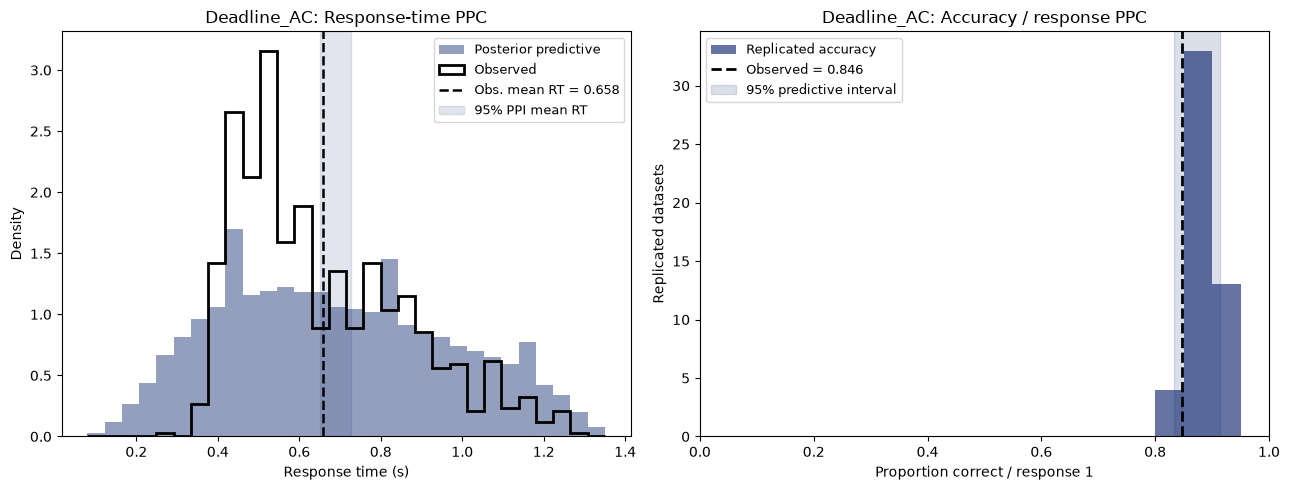

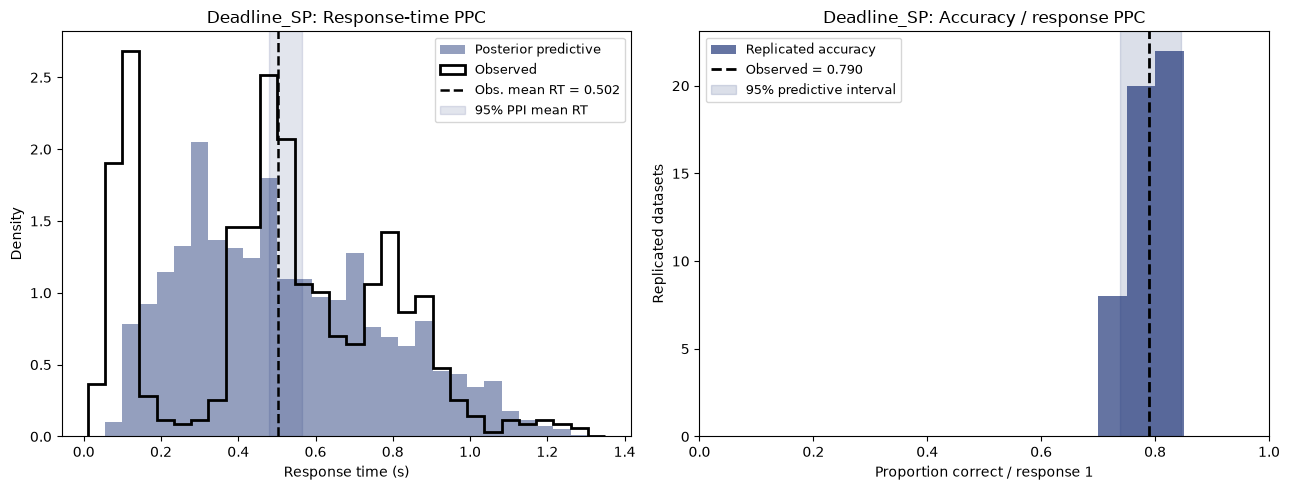

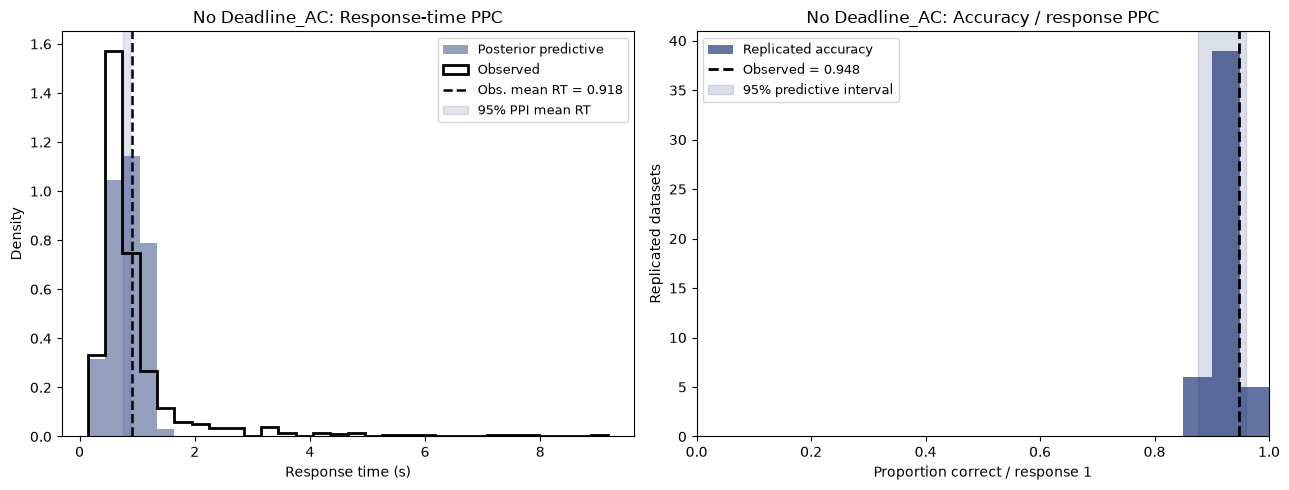

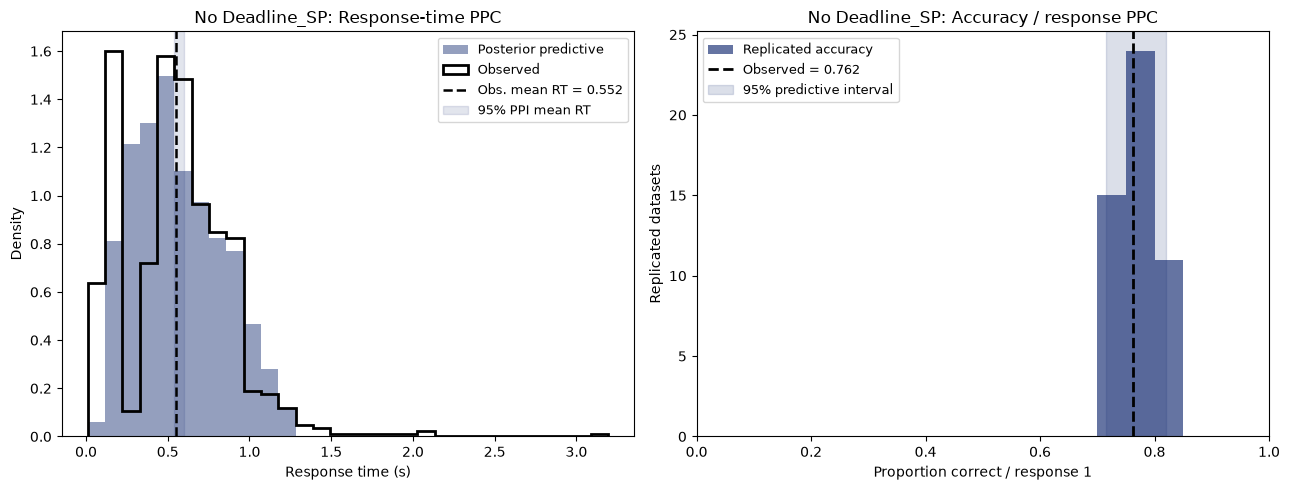

,n_observed_trials,n_replicated_datasets,observed_accuracy,predicted_accuracy_mean,predicted_accuracy_q025,predicted_accuracy_q975,accuracy_inside_95ppi,observed_mean_rt,predicted_mean_rt_mean,predicted_mean_rt_q025,...,predicted_rt_q90_q975,rt_q90_inside_95ppi,observed_correct_mean_rt,predicted_correct_mean_rt_mean,predicted_correct_mean_rt_q025,predicted_correct_mean_rt_q975,observed_error_mean_rt,predicted_error_mean_rt_mean,predicted_error_mean_rt_q025,predicted_error_mean_rt_q975
condition,,,,,,,,,,,,,,,,,,,,,
Deadline_AC,800,50,0.84625,0.883675,0.833500,0.913750,True,0.658259,0.689148,0.651645,...,1.1355,False,0.638000,0.667576,0.624483,0.701172,0.769763,0.854629,0.802010,0.911264
Deadline_SP,800,50,0.79000,0.785775,0.738344,0.845531,True,0.501781,0.517692,0.480517,...,0.9555,True,0.531656,0.500930,0.462405,0.548009,0.389394,0.580809,0.535937,0.636630
No Deadline_AC,800,50,0.94750,0.922675,0.876438,0.960688,True,0.917616,0.827693,0.749763,...,1.2400,False,0.904350,0.806686,0.742254,0.845200,1.157030,1.084769,1.009220,1.155189
No Deadline_SP,800,50,0.76250,0.770650,0.714594,0.820812,True,0.551901,0.568265,0.535857,...,1.0000,True,0.599824,0.547297,0.518639,0.576411,0.398040,0.639934,0.593735,0.707581


In [74]:
ppc_rows = []

for condition_id, condition_label in enumerate(condition_order):
    condition_posterior = {
        parameter: np.asarray(values[condition_id]).squeeze()
        for parameter, values in posterior_samples.items()
        if parameter in ["nu", "k", "a0"]
    }

    figure, statistics = ppc_ddm(
        posterior=condition_posterior,
        trial_simulator=simulate_ddm_trial,
        obs_rt=data_inference_dict["rt"][condition_id].squeeze(),
        obs_acc=data_inference_dict["acc"][condition_id].squeeze(),
        n_reps=50,
        seed=42 + condition_id,
        condition_name=condition_label,
    )

    ppc_rows.append({
        "condition": condition_label,
        **statistics,
    })

    plt.show()

ppc_summary = (
    pd.DataFrame(ppc_rows)
    .set_index("condition")
)

ppc_summary

In [ ]:
# # Run a condition-specific PPC for every inferred data set.
# ppc_rows = []
# for condition_id, condition_label in enumerate(condition_labels):
#     condition_posterior = {
#         key: values[condition_id] for key, values in posterior_samples.items()
#     }
#     fig, statistics = ppc_ddm(
#         posterior=condition_posterior,
#         trial_simulator=simulate_ddm_trial,
#         obs_rt=data_inference_dict["rt"][condition_id].squeeze(),
#         obs_acc=data_inference_dict["acc"][condition_id].squeeze(),
#         n_reps=50,
#         seed=42 + condition_id,
#     )
#     fig.suptitle(condition_label, y=1.03)
#     ppc_rows.append({"condition": condition_label, **statistics})
#     plt.show()

# ppc_summary = pd.DataFrame(ppc_rows).set_index("condition")
# ppc_summary